In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

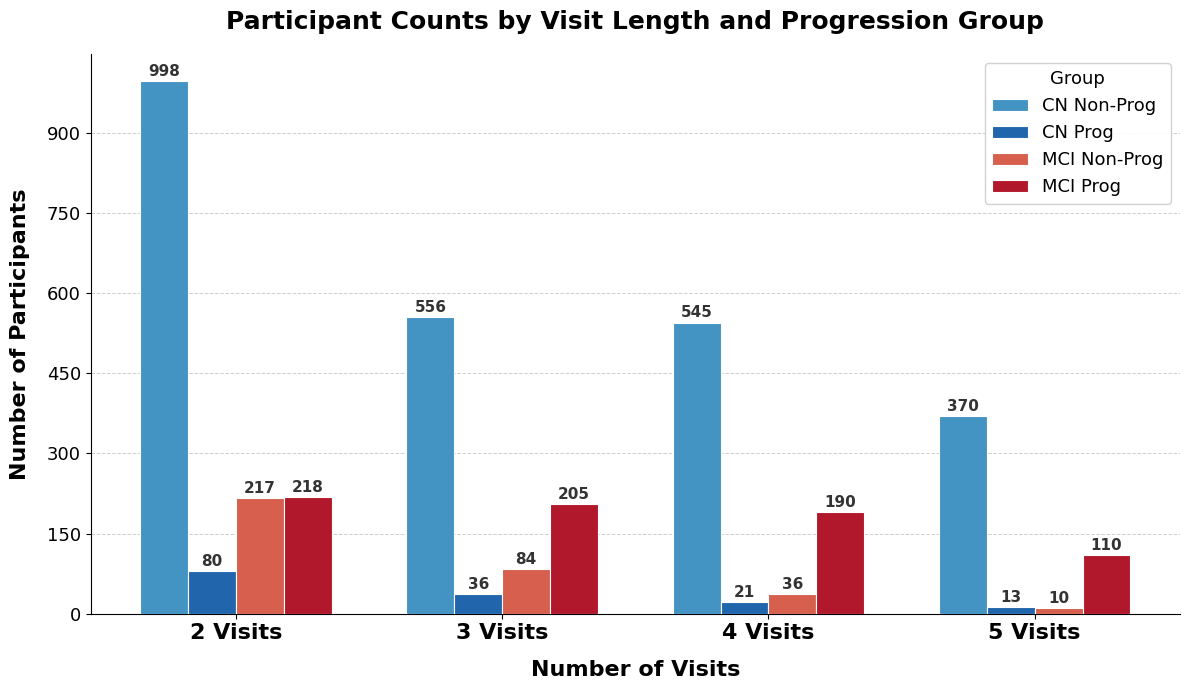

Saved → poster_group_barchart.png
          CN Non-Prog  CN Prog  MCI Non-Prog  MCI Prog
2 Visits          998       80           217       218
3 Visits          556       36            84       205
4 Visits          545       21            36       190
5 Visits          370       13            10       110


In [2]:

import ast

# ── Load data ──────────────────────────────────────────────────────────────────
cn_df  = pd.read_csv("datasets/Dataset_pooled/pooled_CN.csv")
mci_df = pd.read_csv("datasets/Dataset_pooled/pooled_MCI_AD.csv")

def parse_prog(s):
    """Convert string like '(0, 1, 1)' to a tuple of ints."""
    return ast.literal_eval(s)

cn_df["prog_tuple"]  = cn_df["Progression"].apply(parse_prog)
mci_df["prog_tuple"] = mci_df["Progression"].apply(parse_prog)

# ── Classify each subject ─────────────────────────────────────────────────────
# CN non-progressor : all 0s  |  CN progressor : contains a 1
cn_df["is_progressor"] = cn_df["prog_tuple"].apply(lambda t: any(x != 0 for x in t))

# MCI non-progressor : all 1s  |  MCI progressor : contains a 2
mci_df["is_progressor"] = mci_df["prog_tuple"].apply(lambda t: any(x == 2 for x in t))

# Number of visits = length of tuple
cn_df["n_visits"]  = cn_df["prog_tuple"].apply(len)
mci_df["n_visits"] = mci_df["prog_tuple"].apply(len)

# ── Count per visit-count for each of the 4 groups ───────────────────────────
visit_counts = [2, 3, 4, 5]

groups = {
    "CN Non-Prog":  cn_df[~cn_df["is_progressor"]],
    "CN Prog":      cn_df[cn_df["is_progressor"]],
    "MCI Non-Prog": mci_df[~mci_df["is_progressor"]],
    "MCI Prog":     mci_df[mci_df["is_progressor"]],
}

counts = {
    label: [int((df["n_visits"] == v).sum()) for v in visit_counts]
    for label, df in groups.items()
}

# ── Plot ───────────────────────────────────────────────────────────────────────
colors = ["#4393C3", "#2166AC", "#D6604D", "#B2182B"]   # blue tones → CN, red tones → MCI

fig, ax = plt.subplots(figsize=(12, 7))

n_groups = len(visit_counts)
n_bars   = len(groups)
bar_w    = 0.18
x        = np.arange(n_groups)

for i, (label, color) in enumerate(zip(groups.keys(), colors)):
    offsets = x + (i - (n_bars - 1) / 2) * bar_w
    bars = ax.bar(offsets, counts[label], bar_w,
                  label=label, color=color, edgecolor="white", linewidth=0.8, zorder=3)
    # value labels on top of each bar
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, h + 4,
                    str(int(h)), ha="center", va="bottom",
                    fontsize=11, fontweight="bold", color="#333333")

# ── Aesthetics ────────────────────────────────────────────────────────────────
ax.set_xticks(x)
ax.set_xticklabels([f"{v} Visits" for v in visit_counts], fontsize=16, fontweight="bold")
ax.set_ylabel("Number of Participants", fontsize=16, fontweight="bold", labelpad=12)
ax.set_xlabel("Number of Visits", fontsize=16, fontweight="bold", labelpad=12)
ax.set_title("Participant Counts by Visit Length and Progression Group",
             fontsize=18, fontweight="bold", pad=18)

ax.tick_params(axis="y", labelsize=13)
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.grid(axis="y", linestyle="--", linewidth=0.7, alpha=0.6, zorder=0)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)

legend = ax.legend(
    title="Group", title_fontsize=13,
    fontsize=13, frameon=True, framealpha=0.9,
    edgecolor="#cccccc", loc="upper right"
)

plt.tight_layout()
plt.savefig("poster_group_barchart.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved → poster_group_barchart.png")

# ── Print counts table ─────────────────────────────────────────────────────────
summary = pd.DataFrame(counts, index=[f"{v} Visits" for v in visit_counts])
print(summary)


/var/folders/j5/6cc1s4850711ycqjnnzgj1j00000gp/T/ipykernel_56356/2978669370.py:144: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 1, 0.95])


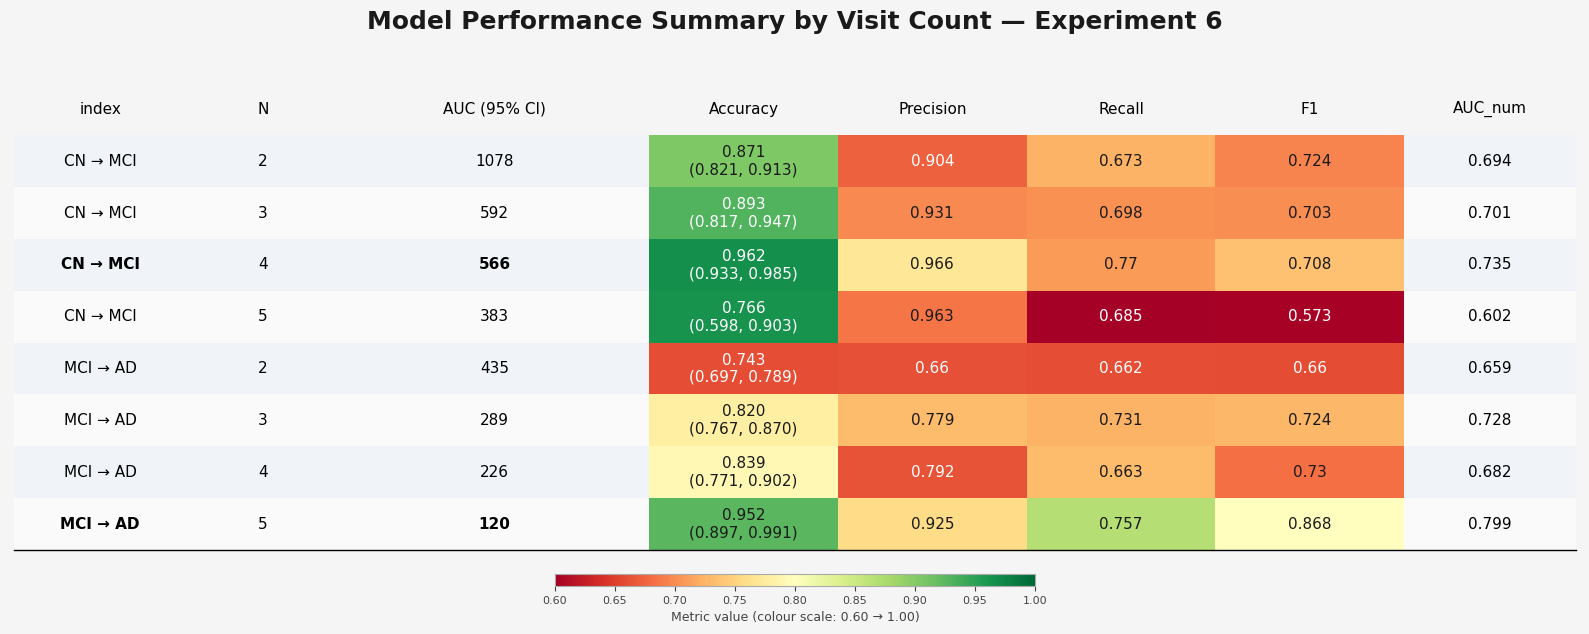

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import RdYlGn
from plottable import Table, ColumnDefinition

# ──────────────────────────────────────────────────────────────────────────────
# Data
# ──────────────────────────────────────────────────────────────────────────────
data_cn_mci = {
    "Visits": [2, 3, 4, 5],
    "N": [1078, 592, 566, 383],
    "AUC (95% CI)": [
        "0.871\n(0.821, 0.913)",
        "0.893\n(0.817, 0.947)",
        "0.962\n(0.933, 0.985)",
        "0.766\n(0.598, 0.903)",
    ],
    "Accuracy": [0.904, 0.931, 0.966, 0.963],
    "Precision": [0.673, 0.698, 0.770, 0.685],
    "Recall": [0.724, 0.703, 0.708, 0.573],
    "F1": [0.694, 0.701, 0.735, 0.602],
}
df_cn_mci = pd.DataFrame(data_cn_mci)

data_mci_ad = {
    "Visits": [2, 3, 4, 5],
    "N": [435, 289, 226, 120],
    "AUC (95% CI)": [
        "0.743\n(0.697, 0.789)",
        "0.820\n(0.767, 0.870)",
        "0.839\n(0.771, 0.902)",
        "0.952\n(0.897, 0.991)",
    ],
    "Accuracy": [0.660, 0.779, 0.792, 0.925],
    "Precision": [0.662, 0.731, 0.663, 0.757],
    "Recall": [0.660, 0.724, 0.730, 0.868],
    "F1": [0.659, 0.728, 0.682, 0.799],
}
df_mci_ad = pd.DataFrame(data_mci_ad)

# Combine
df_cn_mci["Transition"] = "CN → MCI"
df_mci_ad["Transition"] = "MCI → AD"
df = pd.concat([df_cn_mci, df_mci_ad], ignore_index=True)
df = df.set_index(["Transition", "Visits"])

# Numeric AUC
df["AUC_num"] = [float(x.split("\n")[0]) for x in df["AUC (95% CI)"]]

colour_columns = ["Accuracy", "Precision", "Recall", "F1"]

# Column definitions
# Note: plottable collapses a MultiIndex into a single "index" column;
# the explicit ColumnDefinition for "N" onward covers the data columns.
col_defs = [
    ColumnDefinition(name="N", title="N", width=0.9),
    ColumnDefinition(name="AUC (95% CI)", title="AUC (95% CI)", width=1.8),
    ColumnDefinition(name="Accuracy", title="Accuracy", width=1.1),
    ColumnDefinition(name="Precision", title="Precision", width=1.1),
    ColumnDefinition(name="Recall", title="Recall", width=1.1),
    ColumnDefinition(name="F1", title="F1", width=1.1),
]

# ──────────────────────────────────────────────────────────────────────────────
# Build table
# ──────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor("#F5F5F5")
ax.set_facecolor("#F5F5F5")

table = Table(
    df,
    ax=ax,
    column_definitions=col_defs,
    textprops={"fontsize": 11, "ha": "center", "va": "center"},
    row_dividers=True,
    footer_divider=True,
    row_divider_kw={"linewidth": 0, "color": "none"},
    column_border_kw={"edgecolor": "#CCCCCC", "linewidth": 0.5},
    col_label_divider_kw={"linewidth": 0},
)

# ──────────────────────────────────────────────────────────────────────────────
# Styling
# ──────────────────────────────────────────────────────────────────────────────
all_rows = list(table.rows.values())

# Alternating row backgrounds
for i, row in enumerate(all_rows):
    if i % 2 == 0:
        row.set_facecolor("#F0F4F8")
    else:
        row.set_facecolor("#FAFAFA")

# Colour metric cells
def metric_cmap(val, vmin=0.6, vmax=1.0):
    norm_val = np.clip((val - vmin) / (vmax - vmin), 0, 1)
    return RdYlGn(norm_val)

for row in all_rows:
    for col_name in colour_columns:
        cell = table.columns[col_name].cells[row.index]
        val = df.iloc[row.index][col_name]
        if pd.notna(val):
            color = metric_cmap(val)
            cell.rectangle_patch.set_facecolor(color)
            r, g, b = color[:3]
            luminance = 0.299 * r + 0.587 * g + 0.114 * b
            cell.text.set_color("white" if luminance < 0.55 else "#1a1a1a")

# Highlight best AUC per transition (bold the index and AUC cells)
for trans in ["CN → MCI", "MCI → AD"]:
    sub = df.loc[trans]
    best_auc_val = sub["AUC_num"].max()
    for visits_idx in sub[sub["AUC_num"] == best_auc_val].index:
        df_pos = df.index.get_loc((trans, visits_idx))
        row = all_rows[df_pos]
        table.columns["index"].cells[row.index].text.set_fontweight("bold")
        table.columns["AUC (95% CI)"].cells[row.index].text.set_fontweight("bold")

# ──────────────────────────────────────────────────────────────────────────────
# Title and colour bar
# ──────────────────────────────────────────────────────────────────────────────
fig.suptitle(
    "Model Performance Summary by Visit Count — Experiment 6",
    fontsize=18,
    fontweight="bold",
    y=0.98,
    color="#1a1a1a",
)

cbar_ax = fig.add_axes([0.35, 0.02, 0.30, 0.02])
norm = plt.Normalize(vmin=0.60, vmax=1.00)
cb = plt.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap="RdYlGn"),
    cax=cbar_ax,
    orientation="horizontal",
)
cb.set_label("Metric value (colour scale: 0.60 → 1.00)", fontsize=9, color="#444444")
cb.ax.tick_params(labelsize=8, colors="#444444")
cb.outline.set_edgecolor("#AAAAAA")

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig("poster_exp6_plottable.png", dpi=300, bbox_inches="tight", facecolor="#F5F5F5")
plt.show()


## Lead-Time Analysis Charts

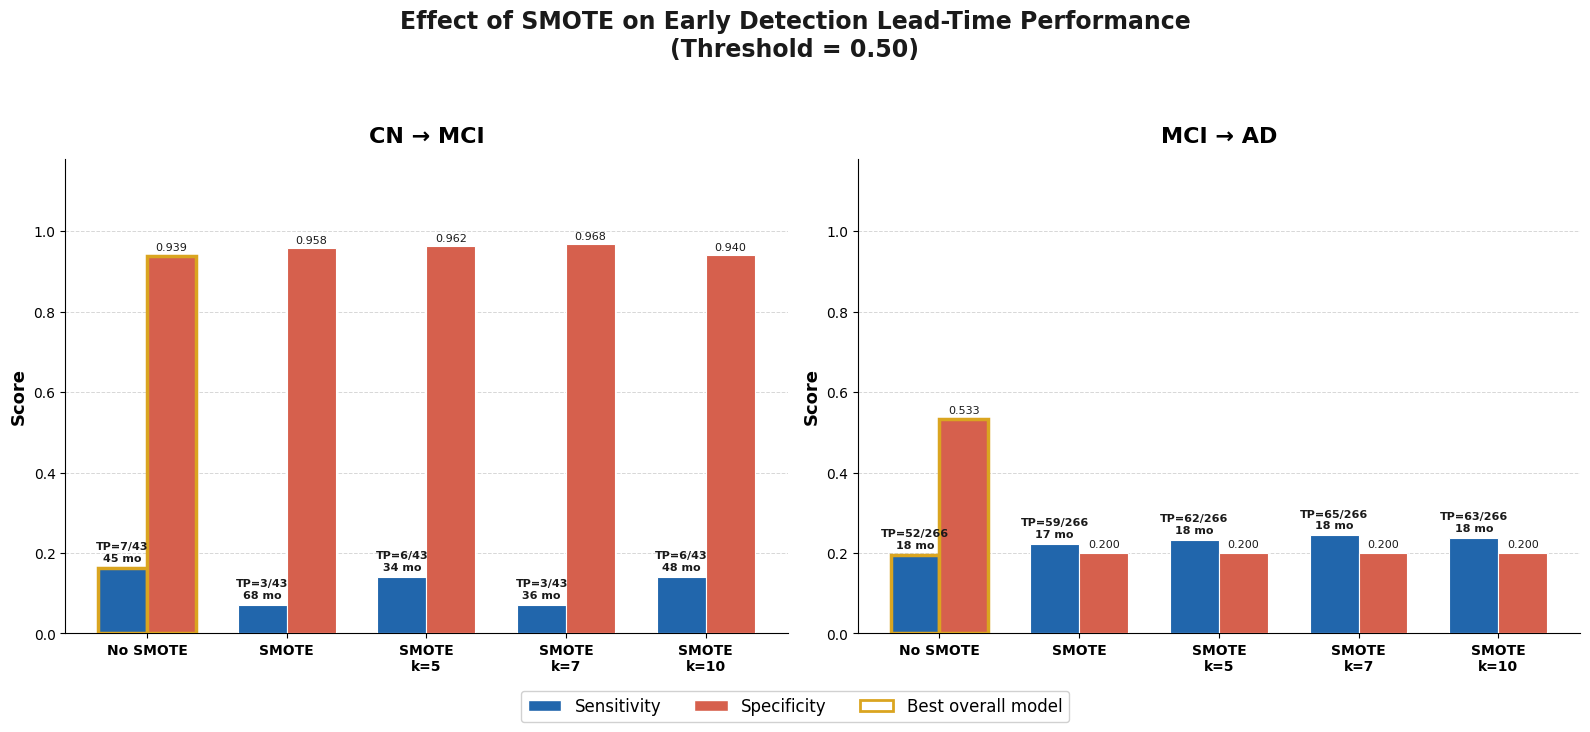

Saved → poster_smote_leadtime.png


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ══════════════════════════════════════════════════════════════════════════════
# Chart 1 — Effect of SMOTE on Lead-Time Detection (threshold = 0.50)
# ══════════════════════════════════════════════════════════════════════════════

models = ["No SMOTE", "SMOTE", "SMOTE\nk=5",
          "SMOTE\nk=7", "SMOTE\nk=10"]

# ── CN → MCI  (threshold = 0.50) ────────────────────────────────────────────
cn_sens  = [0.163, 0.070, 0.140, 0.070, 0.140]
cn_spec  = [0.939, 0.958, 0.962, 0.968, 0.940]
cn_tp    = [7, 3, 6, 3, 6]
cn_lead  = [44.6, 68.0, 34.0, 36.0, 48.0]

# ── MCI → AD  (threshold = 0.50) ────────────────────────────────────────────
ad_sens  = [0.195, 0.222, 0.233, 0.244, 0.237]
ad_spec  = [0.533, 0.200, 0.200, 0.200, 0.200]
ad_tp    = [52, 59, 62, 65, 63]
ad_lead  = [17.5, 17.3, 17.6, 17.5, 18.1]

# ── Colours ──────────────────────────────────────────────────────────────────
c_sens = "#2166AC"   # dark blue  — sensitivity
c_spec = "#D6604D"   # warm red   — specificity

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, cohort, sens, spec, tp, lead, total_prog in zip(
        axes,
        ["CN → MCI", "MCI → AD"],
        [cn_sens, ad_sens],
        [cn_spec, ad_spec],
        [cn_tp, ad_tp],
        [cn_lead, ad_lead],
        [43, 266]):

    x = np.arange(len(models))
    w = 0.35

    # Sensitivity bars
    bars_s = ax.bar(x - w/2, sens, w, color=c_sens, edgecolor="white",
                    linewidth=0.8, label="Sensitivity", zorder=3)
    # Specificity bars
    bars_p = ax.bar(x + w/2, spec, w, color=c_spec, edgecolor="white",
                    linewidth=0.8, label="Specificity", zorder=3)

    # Highlight no-SMOTE bar with a gold border
    for bar in [bars_s[0], bars_p[0]]:
        bar.set_edgecolor("#DAA520")
        bar.set_linewidth(2.5)

    # Annotate TP counts on sensitivity bars
    for i, (bar, t, ld) in enumerate(zip(bars_s, tp, lead)):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.012,
                f"TP={t}/{total_prog}\n{ld:.0f} mo",
                ha="center", va="bottom", fontsize=8, fontweight="bold",
                color="#1a1a1a")

    # Annotate specificity values on top
    for bar in bars_p:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.008,
                f"{h:.3f}", ha="center", va="bottom", fontsize=8,
                color="#1a1a1a")

    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=10, fontweight="bold")
    ax.set_ylim(0, 1.18)
    ax.set_ylabel("Score", fontsize=13, fontweight="bold")
    ax.set_title(cohort, fontsize=16, fontweight="bold", pad=12)
    ax.grid(axis="y", linestyle="--", linewidth=0.7, alpha=0.5, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

# ── Shared legend ─────────────────────────────────────────────────────────────
handles = [mpatches.Patch(facecolor=c_sens, edgecolor="white", label="Sensitivity"),
           mpatches.Patch(facecolor=c_spec, edgecolor="white", label="Specificity"),
           mpatches.Patch(facecolor="none", edgecolor="#DAA520", linewidth=2, label="Best overall model")]
fig.legend(handles=handles, loc="lower center", ncol=3, fontsize=12,
           frameon=True, framealpha=0.9, edgecolor="#cccccc",
           bbox_to_anchor=(0.5, -0.02))

fig.suptitle("Effect of SMOTE on Early Detection Lead-Time Performance\n(Threshold = 0.50)",
             fontsize=17, fontweight="bold", y=1.01, color="#1a1a1a")

plt.tight_layout(rect=[0, 0.04, 1, 0.96])
plt.savefig("poster_smote_leadtime.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved → poster_smote_leadtime.png")

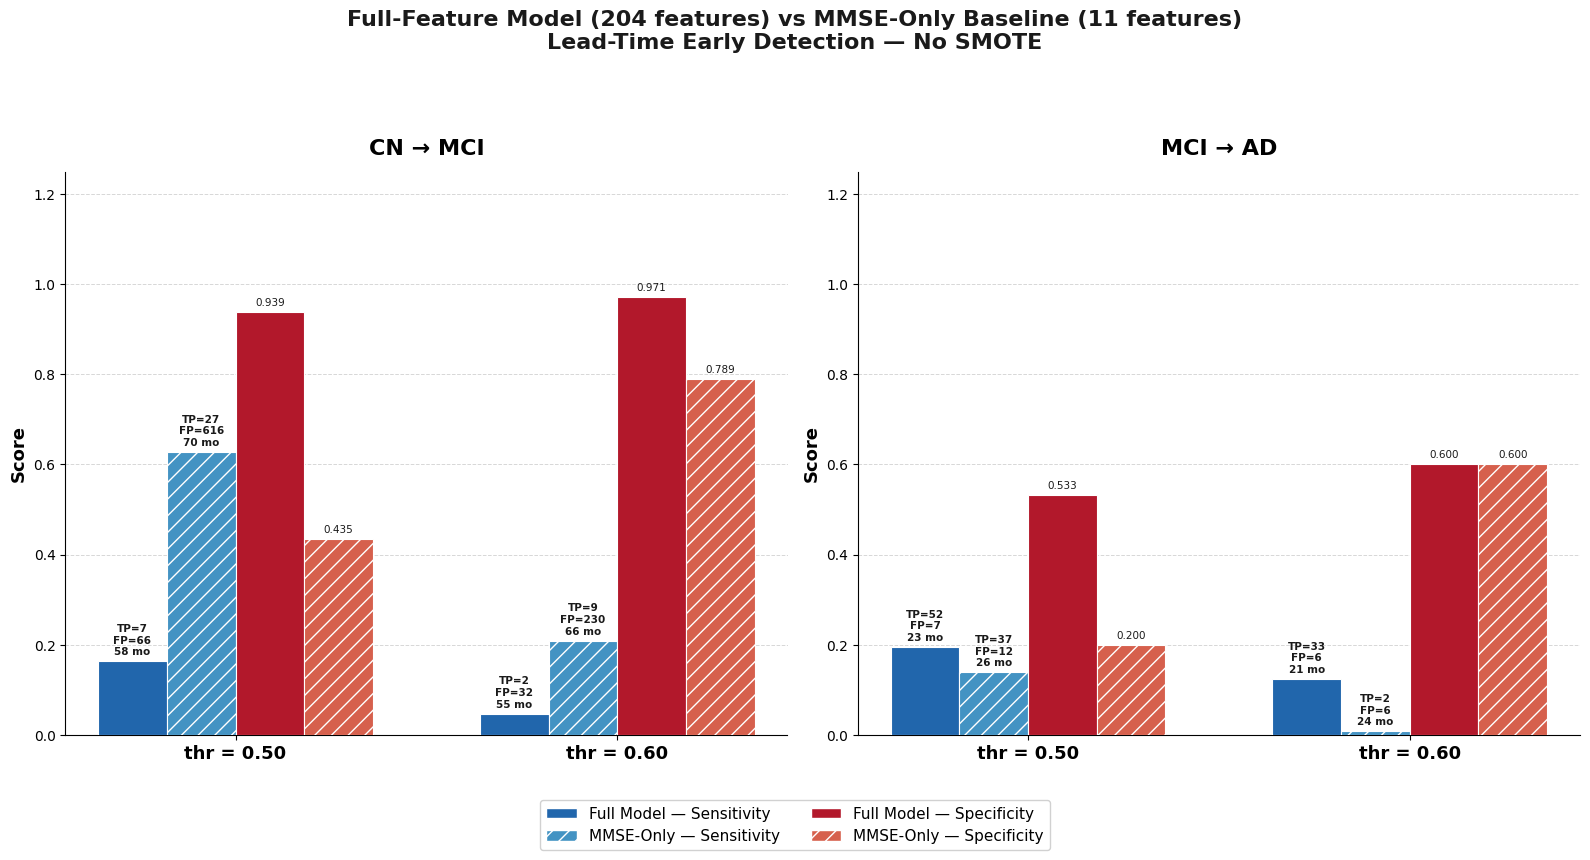

Saved → poster_full_vs_mmse_leadtime.png


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ══════════════════════════════════════════════════════════════════════════════
# Chart 2 — Full-Feature Model (no SMOTE) vs MMSE-Only Baseline
#            Lead-Time Comparison at thresholds 0.50 and 0.60
# ══════════════════════════════════════════════════════════════════════════════

thresholds = [0.50, 0.60]
thr_labels = ["thr = 0.50", "thr = 0.60"]

# ── CN → MCI ────────────────────────────────────────────────────────────────
cn_full = {
    "Sens": [0.163, 0.047], "Spec": [0.939, 0.971],
    "TP": [7, 2], "FP": [66, 32], "Lead": [58.3, 55.0],
}
cn_mmse = {
    "Sens": [0.628, 0.209], "Spec": [0.435, 0.789],
    "TP": [27, 9], "FP": [616, 230], "Lead": [70.4, 66.3],
}

# ── MCI → AD ────────────────────────────────────────────────────────────────
ad_full = {
    "Sens": [0.195, 0.124], "Spec": [0.533, 0.600],
    "TP": [52, 33], "FP": [7, 6], "Lead": [22.9, 20.9],
}
ad_mmse = {
    "Sens": [0.139, 0.008], "Spec": [0.200, 0.600],
    "TP": [37, 2], "FP": [12, 6], "Lead": [25.5, 23.5],
}

# ── Colours ──────────────────────────────────────────────────────────────────
c_full = "#2166AC"   # dark blue  — full model
c_mmse = "#4393C3"   # light blue — MMSE only

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, cohort, full, mmse, total_prog in zip(
        axes,
        ["CN → MCI", "MCI → AD"],
        [cn_full, ad_full],
        [cn_mmse, ad_mmse],
        [43, 266]):

    # Two groups (thr 0.50, thr 0.60) × 2 metrics (Sens, Spec) × 2 models
    group_labels = []
    full_sens_vals, mmse_sens_vals = [], []
    full_spec_vals, mmse_spec_vals = [], []

    for j in range(len(thresholds)):
        full_sens_vals.append(full["Sens"][j])
        mmse_sens_vals.append(mmse["Sens"][j])
        full_spec_vals.append(full["Spec"][j])
        mmse_spec_vals.append(mmse["Spec"][j])
        group_labels.append(thr_labels[j])

    x = np.arange(len(thresholds))
    w = 0.18

    # Four bar groups per threshold: Full-Sens, MMSE-Sens, Full-Spec, MMSE-Spec
    b1 = ax.bar(x - 1.5*w, full_sens_vals, w, color=c_full, edgecolor="white",
                linewidth=0.8, zorder=3)
    b2 = ax.bar(x - 0.5*w, mmse_sens_vals, w, color=c_mmse, edgecolor="white",
                linewidth=0.8, zorder=3, hatch="//")
    b3 = ax.bar(x + 0.5*w, full_spec_vals, w, color="#B2182B", edgecolor="white",
                linewidth=0.8, zorder=3)
    b4 = ax.bar(x + 1.5*w, mmse_spec_vals, w, color="#D6604D", edgecolor="white",
                linewidth=0.8, zorder=3, hatch="//")

    # Annotate bars with TP/FP and lead time
    for j in range(len(thresholds)):
        # Full-model sensitivity annotation
        h = b1[j].get_height()
        ax.text(b1[j].get_x() + w/2, h + 0.01,
                f"TP={full['TP'][j]}\nFP={full['FP'][j]}\n{full['Lead'][j]:.0f} mo",
                ha="center", va="bottom", fontsize=7.5, fontweight="bold", color="#1a1a1a")
        # MMSE sensitivity annotation
        h = b2[j].get_height()
        ax.text(b2[j].get_x() + w/2, h + 0.01,
                f"TP={mmse['TP'][j]}\nFP={mmse['FP'][j]}\n{mmse['Lead'][j]:.0f} mo",
                ha="center", va="bottom", fontsize=7.5, fontweight="bold", color="#1a1a1a")
        # Specificity value annotations
        for bar in [b3[j], b4[j]]:
            h = bar.get_height()
            ax.text(bar.get_x() + w/2, h + 0.01,
                    f"{h:.3f}", ha="center", va="bottom", fontsize=7.5, color="#1a1a1a")

    ax.set_xticks(x)
    ax.set_xticklabels(group_labels, fontsize=13, fontweight="bold")
    ax.set_ylim(0, 1.25)
    ax.set_ylabel("Score", fontsize=13, fontweight="bold")
    ax.set_title(cohort, fontsize=16, fontweight="bold", pad=12)
    ax.grid(axis="y", linestyle="--", linewidth=0.7, alpha=0.5, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

# ── Shared legend ─────────────────────────────────────────────────────────────
handles = [
    mpatches.Patch(facecolor=c_full, edgecolor="white", label="Full Model — Sensitivity"),
    mpatches.Patch(facecolor=c_mmse, edgecolor="white", hatch="//", label="MMSE-Only — Sensitivity"),
    mpatches.Patch(facecolor="#B2182B", edgecolor="white", label="Full Model — Specificity"),
    mpatches.Patch(facecolor="#D6604D", edgecolor="white", hatch="//", label="MMSE-Only — Specificity"),
]
fig.legend(handles=handles, loc="lower center", ncol=2, fontsize=11,
           frameon=True, framealpha=0.9, edgecolor="#cccccc",
           bbox_to_anchor=(0.5, -0.04))

fig.suptitle(
    "Full-Feature Model (204 features) vs MMSE-Only Baseline (11 features)\n"
    "Lead-Time Early Detection — No SMOTE",
    fontsize=16, fontweight="bold", y=1.02, color="#1a1a1a")

plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.savefig("poster_full_vs_mmse_leadtime.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved → poster_full_vs_mmse_leadtime.png")

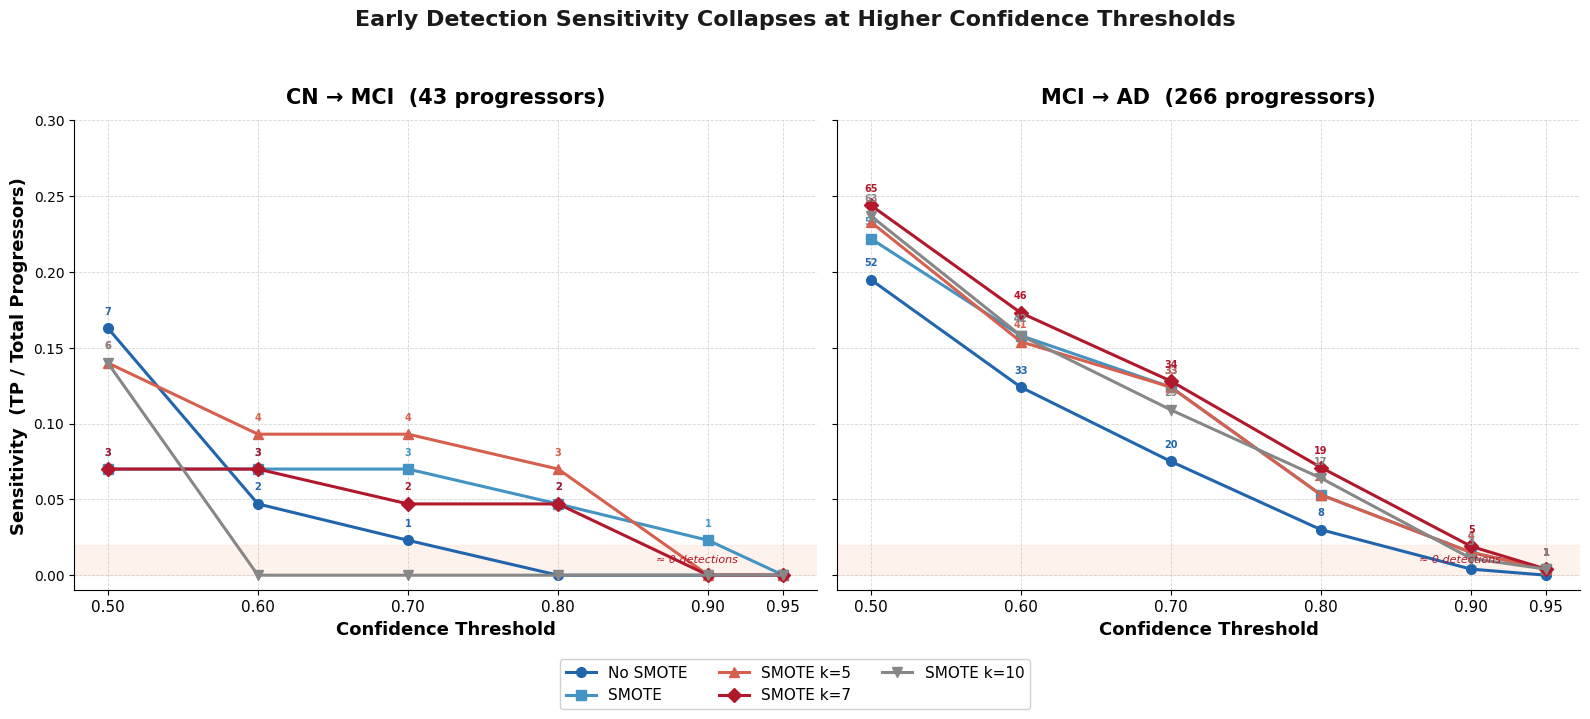

Saved → poster_threshold_collapse.png


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# ══════════════════════════════════════════════════════════════════════════════
# Chart 3 — Sensitivity & TP Collapse Across Increasing Thresholds
#            All 5 SMOTE variants, both cohorts
# ══════════════════════════════════════════════════════════════════════════════

thresholds = [0.50, 0.60, 0.70, 0.80, 0.90, 0.95]

# ── CN → MCI  Sensitivity per model at each threshold ────────────────────────
cn_data = {
    "No SMOTE":   [0.163, 0.047, 0.023, 0.000, 0.000, 0.000],
    "SMOTE":      [0.070, 0.070, 0.070, 0.047, 0.023, 0.000],
    "SMOTE k=5":  [0.140, 0.093, 0.093, 0.070, 0.000, 0.000],
    "SMOTE k=7": [0.070, 0.070, 0.047, 0.047, 0.000, 0.000],
    "SMOTE k=10":[0.140, 0.000, 0.000, 0.000, 0.000, 0.000],
}
# TP counts (for annotation)
cn_tp = {
    "No SMOTE":   [7, 2, 1, 0, 0, 0],
    "SMOTE":      [3, 3, 3, 2, 1, 0],
    "SMOTE k=5":  [6, 4, 4, 3, 0, 0],
    "SMOTE k=7": [3, 3, 2, 2, 0, 0],
    "SMOTE k=10":[6, 0, 0, 0, 0, 0],
}

# ── MCI → AD  Sensitivity per model at each threshold ────────────────────────
ad_data = {
    "No SMOTE":   [0.195, 0.124, 0.075, 0.030, 0.004, 0.000],
    "SMOTE":      [0.222, 0.158, 0.124, 0.053, 0.015, 0.004],
    "SMOTE k=5":  [0.233, 0.154, 0.124, 0.053, 0.015, 0.004],
    "SMOTE k=7": [0.244, 0.173, 0.128, 0.071, 0.019, 0.004],
    "SMOTE k=10":[0.237, 0.158, 0.109, 0.064, 0.011, 0.004],
}
ad_tp = {
    "No SMOTE":   [52, 33, 20, 8, 1, 0],
    "SMOTE":      [59, 42, 33, 14, 4, 1],
    "SMOTE k=5":  [62, 41, 33, 14, 4, 1],
    "SMOTE k=7": [65, 46, 34, 19, 5, 1],
    "SMOTE k=10":[63, 42, 29, 17, 3, 1],
}

# ── Colours & markers ────────────────────────────────────────────────────────
colors  = ["#2166AC", "#4393C3", "#D6604D", "#B2182B", "#878787"]
markers = ["o", "s", "^", "D", "v"]

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

for ax, cohort, data, tp_data, total_prog in zip(
        axes,
        ["CN → MCI  (43 progressors)", "MCI → AD  (266 progressors)"],
        [cn_data, ad_data],
        [cn_tp, ad_tp],
        [43, 266]):

    for (model, sens), color, marker, tp_vals in zip(
            data.items(), colors, markers, tp_data.values()):
        ax.plot(thresholds, sens, marker=marker, color=color, linewidth=2.2,
                markersize=7, label=model, zorder=3)

        # Annotate TP count at each point
        for j, (thr, s, tp) in enumerate(zip(thresholds, sens, tp_vals)):
            if tp > 0:
                ax.annotate(f"{tp}", (thr, s),
                            textcoords="offset points", xytext=(0, 10),
                            ha="center", fontsize=7, fontweight="bold",
                            color=color)

    # Shaded "clinically useless" zone
    ax.axhspan(0, 0.02, color="#fee0d2", alpha=0.4, zorder=0)
    ax.text(0.92, 0.01, "≈ 0 detections", fontsize=8, ha="right",
            va="center", color="#B2182B", fontstyle="italic")

    ax.set_xlabel("Confidence Threshold", fontsize=13, fontweight="bold")
    ax.set_xticks(thresholds)
    ax.set_xticklabels([f"{t:.2f}" for t in thresholds], fontsize=11)
    ax.set_title(cohort, fontsize=15, fontweight="bold", pad=12)
    ax.grid(axis="both", linestyle="--", linewidth=0.6, alpha=0.5, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("Sensitivity  (TP / Total Progressors)", fontsize=13, fontweight="bold")
axes[0].set_ylim(-0.01, 0.30)

# ── Shared legend ─────────────────────────────────────────────────────────────
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, fontsize=11,
           frameon=True, framealpha=0.9, edgecolor="#cccccc",
           bbox_to_anchor=(0.5, -0.04))

fig.suptitle(
    "Early Detection Sensitivity Collapses at Higher Confidence Thresholds",
    fontsize=16, fontweight="bold", y=0.97, color="#1a1a1a")

plt.tight_layout(rect=[0, 0.05, 1, 0.93])
plt.savefig("poster_threshold_collapse.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved → poster_threshold_collapse.png")

### Final AUROC curve chart


- Stratified K fold without SMOTE 
    - CN->MCI
        Dataset base: pooled_CN
        Progression type: CN
        MMSE imputation: post-split (train-fit)
        CV method: skf
        Class balancing: disabled
        Best hyperparameters:
        objective: binary:logistic
        colsample_bytree: 0.6
        eval_metric: auc
        learning_rate: 0.01
        max_depth: 9
        n_estimators: 100
        random_state: 42
        subsample: 0.4
    - MCI->AD
        Dataset base: pooled_MCI_AD
        Progression type: AD
        MMSE imputation: post-split (train-fit)
        CV method: skf
        Class balancing: disabled
        Best hyperparameters:
        objective: binary:logistic
        colsample_bytree: 1.0
        eval_metric: auc
        learning_rate: 0.01
        max_depth: 3
        n_estimators: 400
        random_state: 42
        subsample: 0.6
- Stratified K fold with SMOTE 
    - CN-> MCI
        Dataset base: pooled_CN
        Progression type: CN
        MMSE imputation: post-split (train-fit)
        CV method: skf
        Class balancing: SMOTENC
        Best hyperparameters:
        objective: binary:logistic
        colsample_bytree: 0.4
        eval_metric: auc
        learning_rate: 0.001
        max_depth: 9
        n_estimators: 200
        random_state: 42
        subsample: 0.6
    - MCI-> AD
        Dataset base: pooled_MCI_AD
        Progression type: AD
        MMSE imputation: post-split (train-fit)
        CV method: skf
        Class balancing: SMOTENC
        Best hyperparameters:
        objective: binary:logistic
        colsample_bytree: 1.0
        eval_metric: auc
        learning_rate: 0.01
        max_depth: 3
        n_estimators: 500
        random_state: 42
        subsample: 1.0

- LOOCV Model
    - CN -> MCI
        Dataset base: pooled_CN
        Progression type: CN
        CV method: loocv (Mode A — no train/test split)
        Class balancing: disabled
        MMSE imputation: per-fold (fit on N-1)
        Total samples: 2619

        Best hyperparameters:
        n_estimators: 100
        max_depth: 9
        learning_rate: 0.01
        subsample: 0.4
        colsample_bytree: 0.6
    - MCI -> AD
        Dataset base: pooled_MCI_AD
        Progression type: AD
        CV method: loocv (Mode A — no train/test split)
        Class balancing: disabled
        MMSE imputation: per-fold (fit on N-1)
        Total samples: 1070

        Best hyperparameters:
        n_estimators: 500
        max_depth: 4
        learning_rate: 0.01
        subsample: 1.0
        colsample_bytree: 0.8
- MMSE only baseline model
    - CN -> MCI
        Dataset base: pooled_CN
        Progression type: CN
        MMSE imputation: post-split (train-fit)
        CV method: skf
        Class balancing: disabled
        Best hyperparameters:
        objective: binary:logistic
        colsample_bytree: 1.0
        eval_metric: auc
        learning_rate: 0.01
        max_depth: 3
        n_estimators: 100
        random_state: 42
        subsample: 1.0
    - MCI_> AD
        Dataset base: pooled_MCI_AD
        Progression type: AD
        MMSE imputation: post-split (train-fit)
        CV method: skf
        Class balancing: disabled
        Best hyperparameters:
        objective: binary:logistic
        colsample_bytree: 1.0
        eval_metric: auc
        learning_rate: 0.001
        max_depth: 3
        n_estimators: 400
        random_state: 42
        subsample: 0.4








In [ ]:

# ══════════════════════════════════════════════════════════════════════════════
# Re-run all 8 models (final evaluation only — no grid search)
# ══════════════════════════════════════════════════════════════════════════════
import importlib
import warnings
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

import model as model_module
importlib.reload(model_module)
from model import (
    create_target_variable_ad, create_target_variable_cn,
    create_delta_features, preprocess_data, build_model_final,
    _loocv_final_evaluation, MMSE_COVARIATES,
)
from preprocessing import fit_mmse_imputer, transform_mmse

warnings.filterwarnings('ignore')

# ── Load datasets ─────────────────────────────────────────────────────────────
cn_df_raw  = pd.read_csv("datasets/Dataset_pooled/pooled_CN.csv")
mci_df_raw = pd.read_csv("datasets/Dataset_pooled/pooled_MCI_AD.csv")

# ── Helper: run SKF final evaluation (replicates train_best_model SKF path) ──
def eval_skf_model(dataset, prog_type, params, use_smote=False, mmse_only=False):
    """Run the SKF data pipeline + build_model_final with given hyperparams.
    Returns the full summary dict (y_true, y_proba, y_pred, feature_names, feature_importances, base_auc)."""
    dataset = dataset.copy()
    if prog_type == 'AD':
        dataset['target'] = dataset.apply(create_target_variable_ad, axis=1)
    else:
        dataset['target'] = dataset.apply(create_target_variable_cn, axis=1)

    covariates = [c for c in MMSE_COVARIATES if c in dataset.columns]
    mmse_needs = ('MMSE' in dataset.columns
                  and dataset['MMSE'].astype(str).str.contains('nan', na=False).any())

    # 80/20 stratified split
    train_idx, test_idx = train_test_split(
        dataset.index, test_size=0.2, random_state=42, stratify=dataset['target'])
    df_train = dataset.loc[train_idx].copy()
    df_test  = dataset.loc[test_idx].copy()

    # MMSE imputation
    if mmse_needs:
        imputer, df_train = fit_mmse_imputer(df_train, covariates)
        df_test = transform_mmse(df_test, covariates, imputer)
    
    # Feature engineering
    y_tr = df_train['target'].values
    y_te = df_test['target'].values
    df_tr_feat = create_delta_features(df_train.drop(columns=['target']))
    df_te_feat = create_delta_features(df_test.drop(columns=['target']))
    df_tr_feat['target'] = y_tr
    df_te_feat['target'] = y_te

    # Preprocess
    proc_train, _, _ = preprocess_data(df_tr_feat, prog_type, mmse_only=mmse_only)
    proc_test,  _, _ = preprocess_data(df_te_feat, prog_type, mmse_only=mmse_only)

    feat_names = [c for c in proc_train.columns if c != 'target']
    for col in feat_names:
        if col not in proc_test.columns:
            proc_test[col] = np.nan
    proc_test = proc_test[feat_names + ['target']]

    X_train = proc_train.drop(columns=['target']).values
    X_test  = proc_test.drop(columns=['target']).values
    y_train = proc_train['target'].values
    y_test  = proc_test['target'].values

    model, columns, imputer, scaler, summary = build_model_final(
        X_train, X_test, y_train, y_test, params, feat_names, use_smote=use_smote)
    return summary

# ── Helper: run LOOCV final evaluation ────────────────────────────────────────
def eval_loocv_model(dataset, prog_type, params, n_jobs=10):
    """Run _loocv_final_evaluation with given best hyperparams.
    Returns the full summary dict."""
    dataset = dataset.copy()
    if prog_type == 'AD':
        dataset['target'] = dataset.apply(create_target_variable_ad, axis=1)
    else:
        dataset['target'] = dataset.apply(create_target_variable_cn, axis=1)

    covariates = [c for c in MMSE_COVARIATES if c in dataset.columns]
    mmse_needs = ('MMSE' in dataset.columns
                  and dataset['MMSE'].astype(str).str.contains('nan', na=False).any())

    summary = _loocv_final_evaluation(
        dataset, params, covariates, mmse_needs,
        use_smote=False, progression_type=prog_type, n_jobs=n_jobs)
    return summary

# ══════════════════════════════════════════════════════════════════════════════
# Best hyperparameters (from markdown cell / experiment reports)
# ══════════════════════════════════════════════════════════════════════════════
cn_configs = {
    "SKF No SMOTE": dict(
        params=dict(n_estimators=100, max_depth=9, learning_rate=0.01, subsample=0.4, colsample_bytree=0.6),
        method='skf', use_smote=False, mmse_only=False),
    "SKF SMOTE": dict(
        params=dict(n_estimators=200, max_depth=9, learning_rate=0.001, subsample=0.6, colsample_bytree=0.4),
        method='skf', use_smote=True, mmse_only=False),
    "LOOCV": dict(
        params=dict(n_estimators=100, max_depth=9, learning_rate=0.01, subsample=0.4, colsample_bytree=0.6),
        method='loocv'),
    "MMSE Baseline": dict(
        params=dict(n_estimators=100, max_depth=3, learning_rate=0.01, subsample=1.0, colsample_bytree=1.0),
        method='skf', use_smote=False, mmse_only=True),
}

ad_configs = {
    "SKF No SMOTE": dict(
        params=dict(n_estimators=400, max_depth=3, learning_rate=0.01, subsample=0.6, colsample_bytree=1.0),
        method='skf', use_smote=False, mmse_only=False),
    "SKF SMOTE": dict(
        params=dict(n_estimators=500, max_depth=3, learning_rate=0.01, subsample=1.0, colsample_bytree=1.0),
        method='skf', use_smote=True, mmse_only=False),
    "LOOCV": dict(
        params=dict(n_estimators=500, max_depth=4, learning_rate=0.01, subsample=1.0, colsample_bytree=0.8),
        method='loocv'),
    "MMSE Baseline": dict(
        params=dict(n_estimators=400, max_depth=3, learning_rate=0.001, subsample=0.4, colsample_bytree=1.0),
        method='skf', use_smote=False, mmse_only=True),
}

# ══════════════════════════════════════════════════════════════════════════════
# Run all 8 evaluations
# ══════════════════════════════════════════════════════════════════════════════
cn_results = {}
for name, cfg in cn_configs.items():
    print(f"\n{'─'*60}\n  CN → MCI : {name}\n{'─'*60}")
    if cfg['method'] == 'loocv':
        cn_results[name] = eval_loocv_model(cn_df_raw, 'CN', cfg['params'], n_jobs=10)
    else:
        cn_results[name] = eval_skf_model(cn_df_raw, 'CN', cfg['params'],
                                          use_smote=cfg['use_smote'], mmse_only=cfg['mmse_only'])
    print(f"  AUC = {cn_results[name]['base_auc']:.4f}")

ad_results = {}
for name, cfg in ad_configs.items():
    print(f"\n{'─'*60}\n  MCI → AD : {name}\n{'─'*60}")
    if cfg['method'] == 'loocv':
        ad_results[name] = eval_loocv_model(mci_df_raw, 'AD', cfg['params'], n_jobs=10)
    else:
        ad_results[name] = eval_skf_model(mci_df_raw, 'AD', cfg['params'],
                                          use_smote=cfg['use_smote'], mmse_only=cfg['mmse_only'])
    print(f"  AUC = {ad_results[name]['base_auc']:.4f}")

print("\n✓ All 8 models evaluated.")


In [ ]:

# ══════════════════════════════════════════════════════════════════════════════
# AUROC Curves — CN → MCI  and  MCI → AD
# ══════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Style per model
style_map = {
    "SKF No SMOTE": dict(color="#2166AC", linestyle="-",  linewidth=2.4),
    "SKF SMOTE":    dict(color="#4393C3", linestyle="--", linewidth=2.4),
    "LOOCV":        dict(color="#B2182B", linestyle="-",  linewidth=2.4),
    "MMSE Baseline": dict(color="#878787", linestyle=":", linewidth=2.4),
}

def plot_auroc(results_dict, cohort_label, save_path):
    fig, ax = plt.subplots(figsize=(8, 7))

    for name, res in results_dict.items():
        fpr, tpr, _ = roc_curve(res['y_true'], res['y_proba'])
        auc_val = res['base_auc']
        sty = style_map[name]
        ax.plot(fpr, tpr, label=f"{name} (AUC = {auc_val:.3f})", **sty)

    ax.plot([0, 1], [0, 1], color="#CCCCCC", linestyle="--", linewidth=1.2, label="Random (AUC = 0.500)")

    ax.set_xlim([-0.01, 1.01])
    ax.set_ylim([-0.01, 1.01])
    ax.set_xlabel("False Positive Rate", fontsize=14, fontweight="bold", labelpad=10)
    ax.set_ylabel("True Positive Rate", fontsize=14, fontweight="bold", labelpad=10)
    ax.set_title(f"AUROC Comparison — {cohort_label}", fontsize=16, fontweight="bold", pad=14)
    ax.tick_params(labelsize=12)
    ax.legend(loc="lower right", fontsize=11, frameon=True, framealpha=0.9, edgecolor="#cccccc")
    ax.grid(alpha=0.3, linestyle="--")
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_aspect("equal")

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved → {save_path}")

plot_auroc(cn_results, "CN → MCI", "poster_auroc_cn_mci.png")
plot_auroc(ad_results, "MCI → AD", "poster_auroc_mci_ad.png")


In [ ]:

# ══════════════════════════════════════════════════════════════════════════════
# Top-10 Feature Importance — all 8 models
# ══════════════════════════════════════════════════════════════════════════════
from model import plot_feature_importance

for cohort_label, results_dict in [("CN → MCI", cn_results), ("MCI → AD", ad_results)]:
    cohort_tag = "cn_mci" if "CN" in cohort_label else "mci_ad"
    for name, res in results_dict.items():
        model_tag = name.lower().replace(" ", "_")
        save_path = f"poster_fi_{cohort_tag}_{model_tag}.png"
        title = f"Top 10 Features — {name} ({cohort_label})"
        plot_feature_importance(
            res['feature_importances'], res['feature_names'],
            top_n=10, title=title, save_path=save_path)
        print(f"Saved → {save_path}")


In [ ]:

# ══════════════════════════════════════════════════════════════════════════════
# Confusion Matrices — all 8 models
# ══════════════════════════════════════════════════════════════════════════════
from model import plot_confusion_mat

cohort_labels_map = {
    "CN → MCI": ["Stable CN", "Progressor"],
    "MCI → AD": ["Stable MCI", "Progressor"],
}

for cohort_label, results_dict in [("CN → MCI", cn_results), ("MCI → AD", ad_results)]:
    cohort_tag = "cn_mci" if "CN" in cohort_label else "mci_ad"
    class_labels = cohort_labels_map[cohort_label]
    for name, res in results_dict.items():
        model_tag = name.lower().replace(" ", "_")
        save_path = f"poster_cm_{cohort_tag}_{model_tag}.png"
        title = f"Confusion Matrix — {name} ({cohort_label})"
        plot_confusion_mat(
            res['y_true'], res['y_pred'],
            class_labels=class_labels, title=title, save_path=save_path)
        print(f"Saved → {save_path}")
